In [4]:
pip install pandas numpy scikit-learn xgboost matplotlib seaborn jupyter

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jupyter_server-2.17.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached argon2_cffi-25.1.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached terminado-0.18.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached argon2_cffi_bindings-25.1.0-cp39-abi3-win_amd64.whl.metadata (7.5 kB)
  Using cached jsonschema_specifications-2025.9.1-py

In [5]:
import pandas as pd
import numpy as np

file_path = 'multi_platform_social_sentiment_evolution.csv'

try:
    df = pd.read_csv(file_path)
    print("--- Đọc file thành công! ---")
except FileNotFoundError:
    print("Không tìm thấy file. Hãy kiểm tra lại đường dẫn.")

print("\nThông tin Dataset:")
print(df.info())


--- Đọc file thành công! ---

Thông tin Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 31 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   post_id                           150000 non-null  str    
 1   platform                          150000 non-null  str    
 2   timestamp                         150000 non-null  str    
 3   date                              150000 non-null  str    
 4   hour_of_day                       150000 non-null  int64  
 5   day_of_week                       150000 non-null  int64  
 6   is_weekend                        150000 non-null  int64  
 7   user_id                           150000 non-null  str    
 8   followers                         150000 non-null  int64  
 9   account_age_days                  150000 non-null  int64  
 10  verified                          150000 non-null  int64  
 11  topic         

In [8]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Extract additional time features (optional)
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month

In [12]:
df['log_followers'] = np.log1p(df['followers'])

In [13]:
# 6. DEFINE FEATURE GROUP
categorical_cols = [
    'platform',
    'topic',
    'language',
    'media_type',
    'sentiment_category',
    'location'
]

numerical_cols = [
    'log_followers',
    'account_age_days',
    'content_length',
    'num_hashtags',
    'sentiment_positive',
    'sentiment_negative',
    'sentiment_neutral',
    'hour_of_day',
    'day_of_week',
    'is_weekend',
    'hours_since_post',
    'toxicity_score'
]


In [14]:
# Target chính
df['target_engagement'] = df['engagement_rate_per_1k_followers']

In [15]:
# dùng percentile để chia high / low engagement
threshold = df['target_engagement'].quantile(0.8)

df['label'] = (df['target_engagement'] > threshold).astype(int)

print("Threshold:", threshold)
print(df['label'].value_counts())

Threshold: 40.0
label
0    120012
1     29988
Name: count, dtype: int64


In [16]:
drop_cols = [
    'post_id',
    'timestamp',
]

df = df.drop(columns=drop_cols)

In [17]:
leakage_cols = [
    'likes',
    'shares',
    'comments',
    'total_engagement',
    'views',
    'engagement_rate_per_1k_followers',
    'viral_coefficient',
    'cross_platform_spread'
]

df = df.drop(columns=leakage_cols)

print("Remaining columns:", df.columns)

Remaining columns: Index(['platform', 'date', 'hour_of_day', 'day_of_week', 'is_weekend',
       'user_id', 'followers', 'account_age_days', 'verified', 'topic',
       'language', 'content_length', 'media_type', 'num_hashtags',
       'sentiment_category', 'sentiment_positive', 'sentiment_negative',
       'sentiment_neutral', 'hours_since_post', 'toxicity_score', 'location',
       'hour', 'day', 'month', 'log_followers', 'target_engagement', 'label'],
      dtype='str')


In [18]:


# Thêm 'cross_platform_spread' vào danh sách cần xóa
leakage_cols = ['label', 'target_engagement']

# Chạy lại bước chia X, y
X = df.drop(columns=leakage_cols, errors='ignore')
y = df['label']

# Sau đó chạy lại toàn bộ flow: Split -> Merge Gephi -> Preprocess -> Train

In [19]:
# 3. Chia tập Train/Test bằng GroupShuffleSplit theo user_id
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df['user_id']))

df_train = df.iloc[train_idx].copy()
df_test = df.iloc[test_idx].copy()

print(f"\n--- Đã chia dữ liệu xong ---")
print(f"Tập Train: {len(df_train)} dòng")
print(f"Tập Test: {len(df_test)} dòng")


--- Đã chia dữ liệu xong ---
Tập Train: 120070 dòng
Tập Test: 29930 dòng


In [20]:
import networkx as nx
from itertools import combinations

# 1. Khởi tạo Graph
G_user = nx.Graph()

# 2. Thêm nodes từ df_train (đã sửa tên biến từ X_train_df thành df_train)
users_train = df_train['user_id'].unique()
G_user.add_nodes_from(users_train)

print(f"Total users in Train: {len(users_train)}")

# 3. Hàm xây dựng cạnh (Đảm bảo dùng đúng các cột trong df_train)
def build_user_graph_from_context(data_source):
    print("Đang tạo các kết nối User-User...")
    # Gom nhóm theo các tiêu chí bạn muốn (location, topic, thời gian)
    # Thêm 'language' vào danh sách groupby
    groups = data_source.groupby(['date', 'hour_of_day', 'topic', 'language'])

    for name, group in groups:
        user_list = group['user_id'].unique()
        if 1 < len(user_list) < 50: 
            for u1, u2 in combinations(user_list, 2):
                if G_user.has_edge(u1, u2):
                    G_user[u1][u2]['weight'] += 1
                else:
                    G_user.add_edge(u1, u2, weight=1)

# 4. Gọi hàm truyền vào df_train
build_user_graph_from_context(df_train)

print(f"Total edges created: {G_user.number_of_edges()}")

Total users in Train: 103644
Đang tạo các kết nối User-User...
Total edges created: 91649


In [173]:
import numpy as np



# Bây giờ mới chạy lệnh xuất file Nodes
nodes_df = pd.DataFrame({'Id': list(G_user.nodes())})

node_info = df_train.groupby('user_id').agg({
    'platform': 'first',
    'location': 'first',
    'log_followers': 'mean',
    'topic': 'first'
}).reset_index()

node_info.rename(columns={'user_id': 'Id'}, inplace=True)
nodes_df = nodes_df.merge(node_info, on='Id', how='left')

nodes_df.to_csv("nodes_cross_platform.csv", index=False)
print("Đã xuất file nodes thành công!")

Đã xuất file nodes thành công!


In [174]:



# ==========================================
# 2. XUẤT FILE EDGES (Edges.csv)
# ==========================================
edges_list = []

# Duyệt qua các cạnh trong đồ thị để lấy Source, Target và Weight
for u, v, data in G_user.edges(data=True):
    edges_list.append({
        'Source': u,
        'Target': v,
        'Weight': data.get('weight', 1),
        'Type': 'Undirected' # Đồ thị vô hướng cho tính chất "xuất hiện chung"
    })

edges_df = pd.DataFrame(edges_list)

# Lưu file Edges
edges_df.to_csv("edges_cross_platform.csv", index=False)
print(f"Đã xuất {len(edges_df)} edges vào file edges_cross_platform.csv")

Đã xuất 91649 edges vào file edges_cross_platform.csv


In [12]:
print(df_train.columns)
print (df_test.columns)

Index(['platform', 'date', 'hour_of_day', 'day_of_week', 'is_weekend',
       'user_id', 'followers', 'account_age_days', 'verified', 'topic',
       'language', 'content_length', 'media_type', 'num_hashtags',
       'sentiment_category', 'sentiment_positive', 'sentiment_negative',
       'sentiment_neutral', 'hours_since_post', 'toxicity_score', 'location',
       'hour', 'day', 'month', 'log_followers', 'target_engagement', 'label'],
      dtype='object')
Index(['platform', 'date', 'hour_of_day', 'day_of_week', 'is_weekend',
       'user_id', 'followers', 'account_age_days', 'verified', 'topic',
       'language', 'content_length', 'media_type', 'num_hashtags',
       'sentiment_category', 'sentiment_positive', 'sentiment_negative',
       'sentiment_neutral', 'hours_since_post', 'toxicity_score', 'location',
       'hour', 'day', 'month', 'log_followers', 'target_engagement', 'label'],
      dtype='object')


In [21]:
import pandas as pd
import numpy as np

# 1. Đọc kết quả mới nhất từ Gephi
df_gephi = pd.read_csv('gephi-result-7.csv')

# 2. Danh sách các đặc trưng đồ thị "đắt giá"
graph_features = [
    'pageranks', 'clustering', 'triangles', 'eigencentrality', 
    'Eccentricity', 'closnesscentrality', 'harmonicclosnesscentrality', 
    'betweenesscentrality', 'Degree', 'Weighted Degree'
]

# 3. Merge vào df_train và df_test
# Lưu ý: Xóa cột trùng nếu bạn đã lỡ merge bản cũ trước đó
df_train = df_train.drop(columns=[c for c in graph_features if c in df_train.columns], errors='ignore')
df_test = df_test.drop(columns=[c for c in graph_features if c in df_test.columns], errors='ignore')

df_train = df_train.merge(df_gephi[['Id'] + graph_features], left_on='user_id', right_on='Id', how='left')
df_test = df_test.merge(df_gephi[['Id'] + graph_features], left_on='user_id', right_on='Id', how='left')

# 4. Lấp đầy khoảng trống cho những người không nằm trong đồ thị
df_train[graph_features] = df_train[graph_features].fillna(0)
df_test[graph_features] = df_test[graph_features].fillna(0)

print("Đã hợp nhất đặc trưng đồ thị thành công!")

Đã hợp nhất đặc trưng đồ thị thành công!


In [22]:
df_train.head()

,platform,date,hour_of_day,day_of_week,is_weekend,user_id,followers,account_age_days,verified,topic,...,pageranks,clustering,triangles,eigencentrality,Eccentricity,closnesscentrality,harmonicclosnesscentrality,betweenesscentrality,Degree,Weighted Degree
0,TikTok,2025-04-19,1,5,1,user_426711,137,306,0,Finance,...,0.000002,0.0,0,0.0,0,0.0,0.0,0,0,0
1,Twitter,2025-04-19,5,5,1,user_221610,1974,2310,0,Food,...,0.000002,0.0,0,0.0,0,0.0,0.0,0,0,0
2,Instagram,2025-04-19,6,5,1,user_313440,1366,2057,0,Education,...,0.000002,0.0,0,0.0,0,0.0,0.0,0,0,0
3,Reddit,2025-04-19,7,5,1,user_19777,124,1400,0,Climate,...,0.000002,0.0,0,0.0,0,0.0,0.0,0,0,0
4,Facebook,2025-04-19,8,5,1,user_157662,265,57,0,Finance,...,0.000002,0.0,0,0.0,0,0.0,0.0,0,0,0


In [23]:
from sklearn.compose import ColumnTransformer


# Cập nhật danh sách numerical bao gồm Metadata và Graph metrics
numerical_cols = [
    'log_followers', 'account_age_days', 'content_length', 'num_hashtags',
    'sentiment_positive', 'sentiment_negative', 'sentiment_neutral',
    'hour_of_day', 'day_of_week', 'hours_since_post', 'toxicity_score'
] + graph_features

# Danh sách categorical (Metadata thô)
categorical_cols = [
    'platform', 'topic', 'language', 'media_type', 
    'sentiment_category', 'location'
]



In [24]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# Định nghĩa và thực thi Preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

X_train_final = preprocessor.fit_transform(df_train)
X_test_final = preprocessor.transform(df_test)

y_train = df_train['label']
y_test = df_test['label']

print(f"Dữ liệu sẵn sàng! Số lượng đặc trưng cuối cùng: {X_train_final.shape[1]}")

Dữ liệu sẵn sàng! Số lượng đặc trưng cuối cùng: 67


In [6]:
pip install node2vec

Note: you may need to restart the kernel to use updated packages.


In [25]:
from node2vec import Node2Vec

node2vec = Node2Vec(G_user, dimensions=64, walk_length=30, num_walks=100, workers=4)
model = node2vec.fit(window=10, min_count=1)

embeddings = []
for node in G_user.nodes():
    vec = model.wv[str(node)]
    embeddings.append([node] + list(vec))

df_emb = pd.DataFrame(embeddings)

Computing transition probabilities:   0%|          | 0/103644 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [26]:
from node2vec import Node2Vec

node2vec = Node2Vec(
    G_user,
    dimensions=16,
    walk_length=10,
    num_walks=10,
    workers=4
)

model = node2vec.fit(
    window=5,
    min_count=1
)

Computing transition probabilities:   0%|          | 0/103644 [00:00<?, ?it/s]

In [29]:
embeddings = []

for node in G_user.nodes():
    vec = model.wv[str(node)]
    embeddings.append([node] + list(vec))

In [30]:
cols = ['user_id'] + [f'emb_{i}' for i in range(16)]   # nếu dimensions=16
df_emb = pd.DataFrame(embeddings, columns=cols)

print(df_emb.shape)
df_emb.head()

(103644, 17)


,user_id,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15
0,user_426711,0.032087,0.039587,0.054947,-0.005615,-0.052291,-0.022957,-0.047264,-0.009725,0.013670,-0.002979,-0.020595,0.046623,0.020330,-0.055990,0.045868,-0.026750
1,user_221610,-0.054969,-0.017817,-0.026361,0.017300,-0.011831,-0.036435,0.019551,0.022071,0.036034,0.028949,-0.021204,-0.013833,0.013177,0.004689,-0.018736,0.037102
2,user_313440,-0.058828,-0.021928,0.033619,-0.037701,0.032925,-0.048552,0.013447,0.007481,-0.035987,-0.046597,0.012892,-0.005850,-0.011028,0.057163,0.049337,-0.058735
3,user_19777,0.059013,-0.027995,-0.053011,-0.011755,0.040585,-0.018329,0.057006,0.032477,-0.008642,0.061842,0.058981,0.018474,0.019310,-0.000685,0.052461,0.023905
4,user_157662,0.017013,-0.051312,-0.032232,0.010083,-0.059479,0.051970,0.017783,-0.033378,0.061761,-0.041255,-0.042567,-0.008260,0.017451,0.051864,-0.014245,-0.027872


In [32]:
embedding_cols = [f'emb_{i}' for i in range(16)]

df_train[embedding_cols] = df_train[embedding_cols].fillna(0)
df_test[embedding_cols]  = df_test[embedding_cols].fillna(0)

In [33]:
numerical_cols = numerical_cols + embedding_cols

In [34]:
# ---------------------------------
# 3. TARGET
# ---------------------------------
X_train = df_train[numerical_cols + categorical_cols]
X_test  = df_test[numerical_cols + categorical_cols]

y_train = df_train['label']
y_test  = df_test['label']

# ---------------------------------
# 4. PREPROCESS
# ---------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [36]:
# ---------------------------------
# 5. XGBOOST MODEL
# ---------------------------------
from xgboost import XGBClassifier
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

In [38]:
# ---------------------------------
# 6. PIPELINE
# ---------------------------------
from sklearn.pipeline import Pipeline
clf = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', model)
])

# ---------------------------------
# 7. TRAIN
# ---------------------------------
clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [40]:
# ---------------------------------
# 8. PREDICT
# ---------------------------------
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# ---------------------------------
# 9. EVALUATE
# ---------------------------------
print("===== Classification Report =====")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", round(auc, 4))

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.84      0.47      0.60     24005
           1       0.22      0.63      0.33      5925

    accuracy                           0.50     29930
   macro avg       0.53      0.55      0.46     29930
weighted avg       0.71      0.50      0.54     29930

ROC-AUC Score: 0.5651


In [41]:
from sklearn.metrics import f1_score

best_t = 0.5
best_f1 = 0

for t in np.arange(0.1, 0.9, 0.02):
    pred = (y_prob >= t).astype(int)
    score = f1_score(y_test, pred)

    if score > best_f1:
        best_f1 = score
        best_t = t

print(best_t, best_f1)

0.42000000000000004 0.3468307613824767


In [42]:
from sklearn.metrics import classification_report

best_pred = (y_prob >= 0.42).astype(int)

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.89      0.17      0.28     24005
           1       0.21      0.92      0.35      5925

    accuracy                           0.32     29930
   macro avg       0.55      0.54      0.31     29930
weighted avg       0.76      0.32      0.29     29930



In [44]:
for t in [0.42, 0.45, 0.48, 0.50, 0.52]:
    pred = (y_prob >= t).astype(int)
    from sklearn.metrics import f1_score
    print(t, f1_score(y_test, pred))

0.42 0.3468307613824767
0.45 0.345879475507847
0.48 0.3415933919531042
0.5 0.331094604812525
0.52 0.2983559273146813


In [18]:
from xgboost import XGBClassifier

# Tính toán tỷ lệ lệch
ratio = 24005 / 5925 

# Khởi tạo lại model với tham số scale_pos_weight
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=ratio, # <--- ĐÂY LÀ CHÌA KHÓA
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train và đánh giá lại
xgb_model.fit(X_train_final, y_train)
y_pred = xgb_model.predict(X_test_final)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred):.4f}")

NameError: name 'classification_report' is not defined

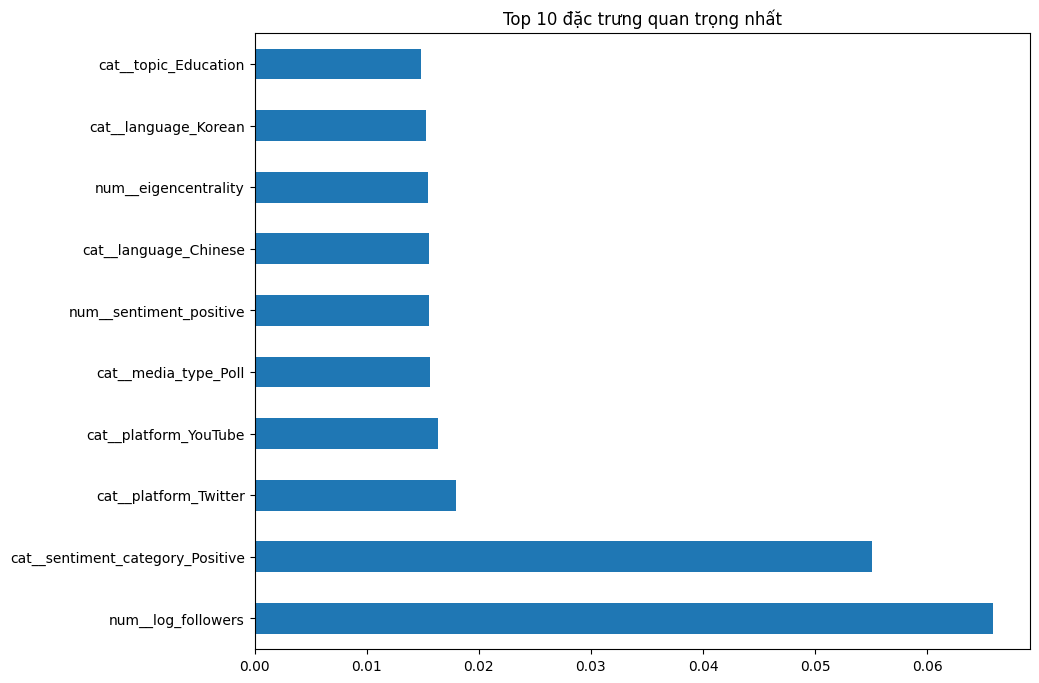

In [180]:
import matplotlib.pyplot as plt

# Lấy tầm quan trọng của các đặc trưng
importances = xgb_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
feat_importances = pd.Series(importances, index=feature_names)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 đặc trưng quan trọng nhất")
plt.show()